## To create an agent With an Inbuilt function
#### we wont be need to create manual tool binding with  the llm/model and creating manual tool calls 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv('gemini_api_key')


In [2]:
from langchain.tools import tool

# """this @tool is a decorator came from langchain.tools library """
@tool
# now we will write the tools function 
def get_weather(location:str)->str :
    """Use the get_weather tool to tell me the weather in Bengaluru."""
    return f"It's sunny  here and the temperature is 25 degree  at {location}"



c:\DEV\devilcode development\Langchain-part2\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:

from langchain.chat_models import init_chat_model
llm = init_chat_model(
    "gemini-3.1-flash-lite-preview", 
    model_provider="google_genai",
    temperature=0 
)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


##### Now here we will use the create_agent method defined in the langchain inbuilt methods 

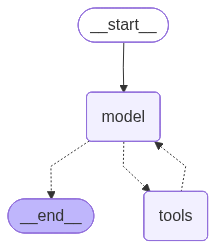

In [4]:

from langchain.agents import create_agent
# create_agent provides a production-ready agent implementation.
agent = create_agent(
    model = llm,
    tools=[get_weather],
    system_prompt="You are a helpful ai "
    )

agent

####now here we will invoke the llm agent 
There is a particular syntax with every kind of mode;l to access the  response in different ways , go to the agents docs for seeing it 

In [5]:
response = agent.invoke({"messages":[{"role":"user", "content":"what is the weather in pakistan"}]})
response

{'messages': [HumanMessage(content='what is the weather in pakistan', additional_kwargs={}, response_metadata={}, id='5445299e-ac1a-4166-901e-f55d0f8986bd'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Pakistan"}'}, '__gemini_function_call_thought_signatures__': {'f0a2661b-adc2-4ccd-8b0a-b5a6982b536a': 'EjQKMgEMOdbHmreWPxSlY2kChV4SmDa1tvHkflSVH6BiqrWW6jGXzD5cHuv0VlfyNDzSX5tc'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9d3c-fe93-7fb2-94eb-ce37a3b65203-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Pakistan'}, 'id': 'f0a2661b-adc2-4ccd-8b0a-b5a6982b536a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'output_tokens': 16, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content="It's sunny  here and the temperature is 25 

In [ ]:
llm.invoke("whats the weather in bhikharistan").text

'"Bhikharistan" is not a real country or a recognized geographical location. It is a derogatory slang term sometimes used in political discourse or social media to refer to Pakistan.\n\nBecause it is not a real place, there is no weather data available for it. If you are looking for the weather in a specific city in Pakistan (such as Islamabad, Karachi, or Lahore), please let me know the city name, and I would be happy to provide the current forecast for you.'

In [ ]:
response['messages'][-1].content

[{'type': 'text',
  'text': 'The weather in Pakistan is currently sunny with a temperature of 25°C.',
  'extras': {'signature': 'EjQKMgG+Pvb7KCEmB5LXNAsizCxUGxasXjnmWjGRHhyLPSNhvGB/xGrCHKIhuyGnB9yr053p'}}]

### Now here even if we ask the agent out of the context tool , questions then also it could handle the cases it self , refer to the agents graph above to understand it the best .

In [ ]:
response = agent.invoke({"messages":[{"role":"user", "content":"what is the national animal of pakistan"}]})
response['messages'][-1].content

[{'type': 'text',
  'text': 'The national animal of Pakistan is the **markhor** (*Capra falconeri*).',
  'extras': {'signature': 'EjQKMgG+Pvb7QHwdxepRpEBikeHacap/XWsh9Ctyo2+laWQ/KuJBY2S6p3fBEmRSg0dnqKvK'}}]